In [1]:
# Prints the path of the active Python environment (used to verify correct virtual environment)
import sys
print(sys.executable)

/Users/shristirai/Desktop/Capstone-Project-main/.venv/bin/python


In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Display confirmation and library versions
print("Libraries loaded successfully")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Libraries loaded successfully
Pandas version: 3.0.1
NumPy version: 2.4.3


In [3]:
# Load dataset
df = pd.read_csv("digital_marketing_campaign_dataset.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
# Display shape
print("Shape of dataset:", df.shape)

Shape of dataset: (8000, 20)


In [5]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool', 'Conversion']


In [6]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   CustomerID  Age  Gender  Income CampaignChannel CampaignType      AdSpend  \
0        8000   56  Female  136912    Social Media    Awareness  6497.870068   
1        8001   69    Male   41760           Email    Retention  3898.668606   
2        8002   46  Female   88456             PPC    Awareness  1546.429596   
3        8003   32  Female   44085             PPC   Conversion   539.525936   
4        8004   60  Female   83964             PPC   Conversion  1678.043573   

   ClickThroughRate  ConversionRate  WebsiteVisits  PagesPerVisit  TimeOnSite  \
0          0.043919        0.088031              0       2.399017    7.396803   
1          0.155725        0.182725             42       2.917138    5.352549   
2          0.277490        0.076423              2       8.223619   13.794901   
3          0.137611        0.088004             47       4.540939   14.688363   
4          0.252851        0.109940              0       2.046847   13.993370   

   SocialShares  

In [7]:
# checking missing values 
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64


In [8]:
# Summary statistics (numerical columns)
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [9]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


In [10]:
# Drop ID column (not useful for analysis)
if "CustomerID" in df.columns:
    df = df.drop(columns=["CustomerID"])

In [11]:
# Identify constant columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print("Constant columns:", constant_cols)

# Drop them
df = df.drop(columns=constant_cols)

Constant columns: ['AdvertisingPlatform', 'AdvertisingTool']


In [12]:
print("Final shape:", df.shape)
print(df.nunique())

Final shape: (8000, 17)
Age                    52
Gender                  2
Income               7789
CampaignChannel         5
CampaignType            4
AdSpend              8000
ClickThroughRate     8000
ConversionRate       8000
WebsiteVisits          50
PagesPerVisit        8000
TimeOnSite           8000
SocialShares          100
EmailOpens             20
EmailClicks            10
PreviousPurchases      10
LoyaltyPoints        3983
Conversion              2
dtype: int64


In [13]:
# Save cleaned dataset
df.to_csv("cleaned_marketing_campaign_data.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_marketing_campaign_data.csv'")


Cleaned dataset saved as 'cleaned_marketing_campaign_data.csv'


Conversion
1    7012
0     988
Name: count, dtype: int64
Conversion
1    87.65
0    12.35
Name: proportion, dtype: float64


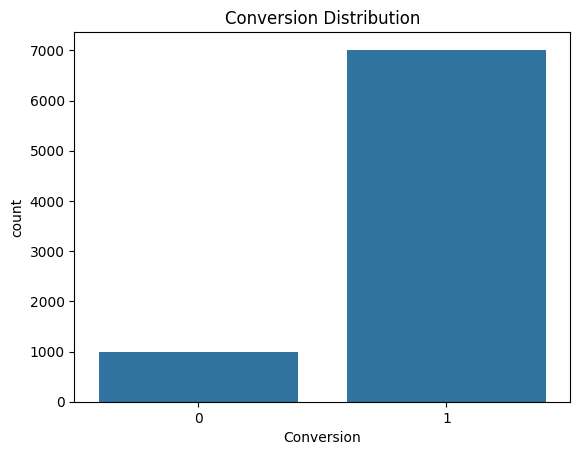

In [14]:
# Analyze distribution of target variable to assess class balance
import seaborn as sns
import matplotlib.pyplot as plt

# Count and percentage of converted vs non-converted customers
print(df['Conversion'].value_counts())
print(df['Conversion'].value_counts(normalize=True) * 100)

# Visualize conversion distribution
sns.countplot(x='Conversion', data=df)
plt.title("Conversion Distribution")
plt.show()

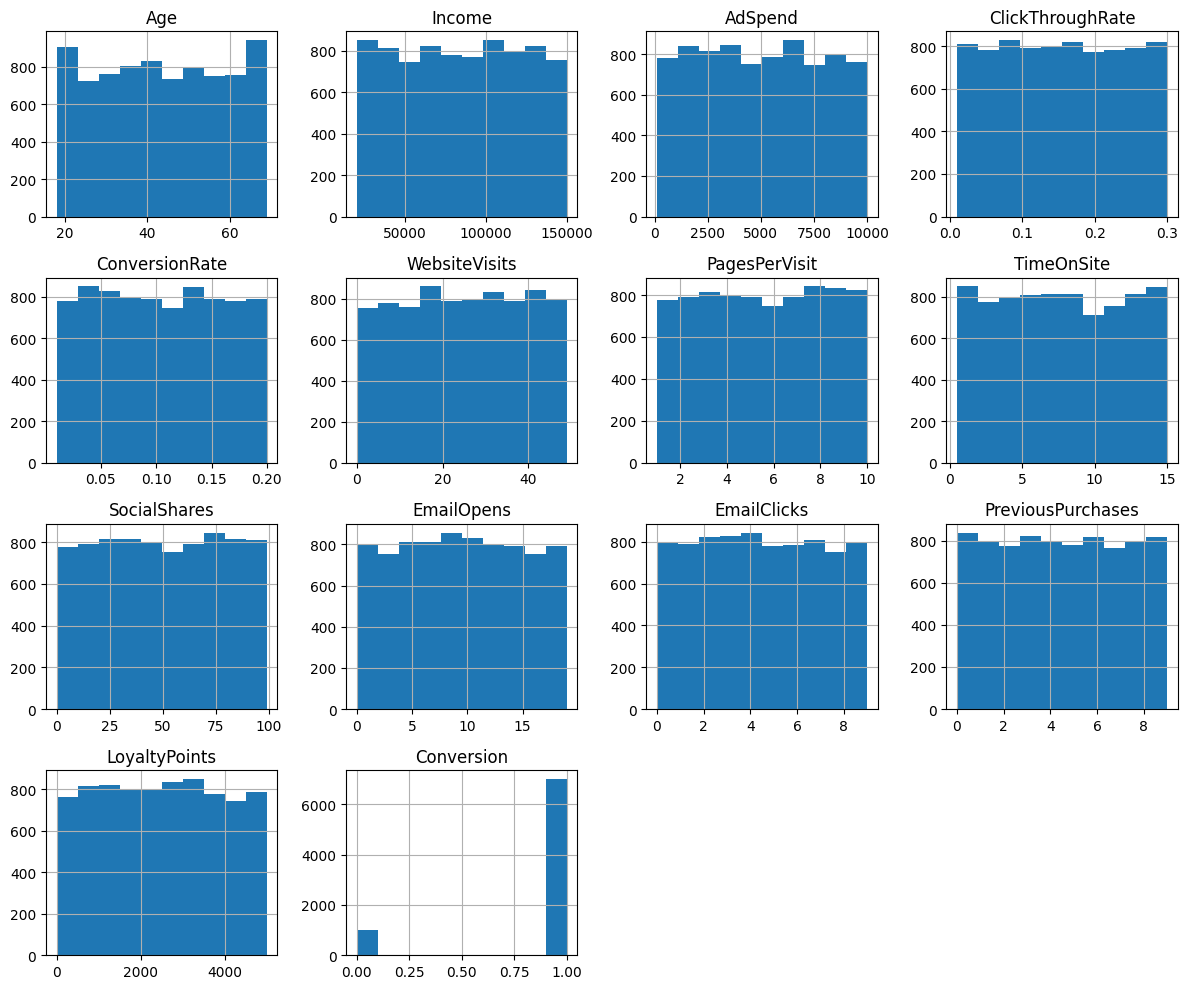

In [15]:
# Visualize distribution of numerical variables to understand spread, patterns, and potential outliers

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

In [16]:
# Analyze distribution of categorical variables to understand frequency of each category

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 Gender
Gender
Female    4839
Male      3161
Name: count, dtype: int64

 CampaignChannel
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64

 CampaignType
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64


/var/folders/q3/y1vfpm8j6j56yld3bzyvkjy80000gn/T/ipykernel_68197/3860396913.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


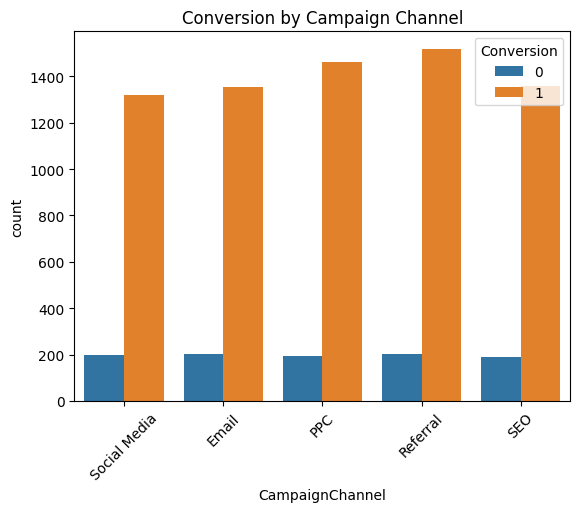

In [17]:
# Compare conversion outcomes across different campaign channels

sns.countplot(x='CampaignChannel', hue='Conversion', data=df)
plt.title("Conversion by Campaign Channel")
plt.xticks(rotation=45)
plt.show()

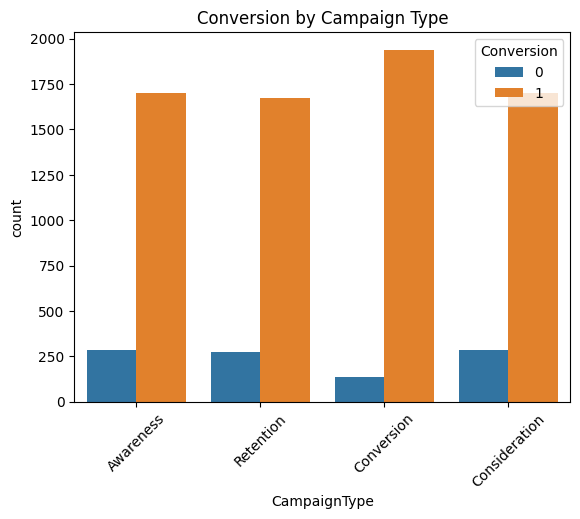

In [18]:
# campaign type
sns.countplot(x='CampaignType', hue='Conversion', data=df)
plt.title("Conversion by Campaign Type")
plt.xticks(rotation=45)
plt.show()

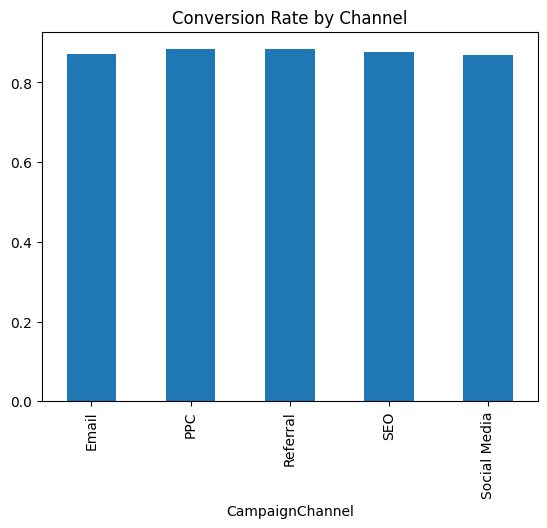

In [19]:
# conversion rate
channel_conversion = df.groupby('CampaignChannel')['Conversion'].mean()
channel_conversion.plot(kind='bar', title="Conversion Rate by Channel")
plt.show()

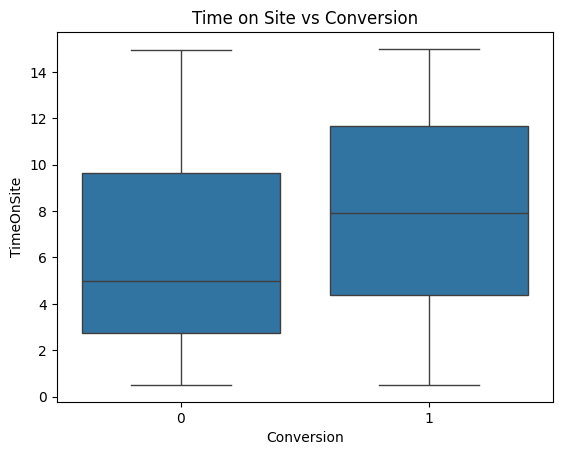

In [20]:
# conversion vs numerical variables
# Observation: Converted users appear to spend more time on site
sns.boxplot(x='Conversion', y='TimeOnSite', data=df)
plt.title("Time on Site vs Conversion")
plt.show()

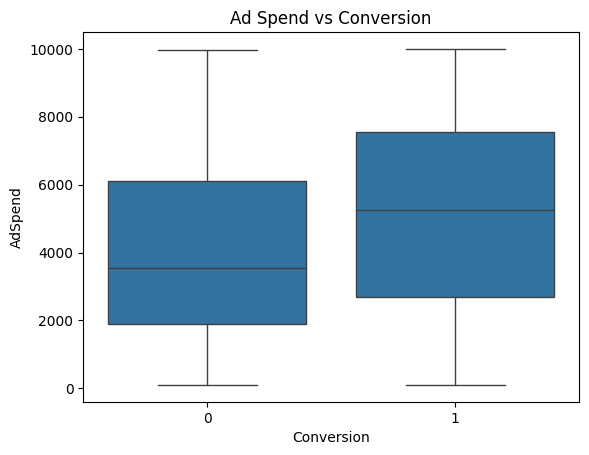

In [21]:
sns.boxplot(x='Conversion', y='AdSpend', data=df)
plt.title("Ad Spend vs Conversion")
plt.show()

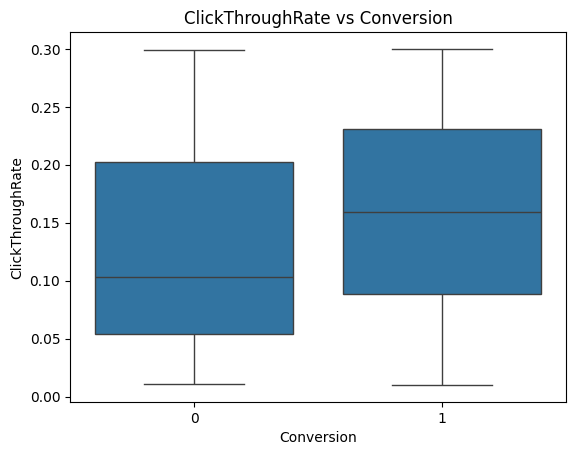

In [22]:
sns.boxplot(x='Conversion', y='ClickThroughRate', data=df)
plt.title("ClickThroughRate vs Conversion")
plt.show()

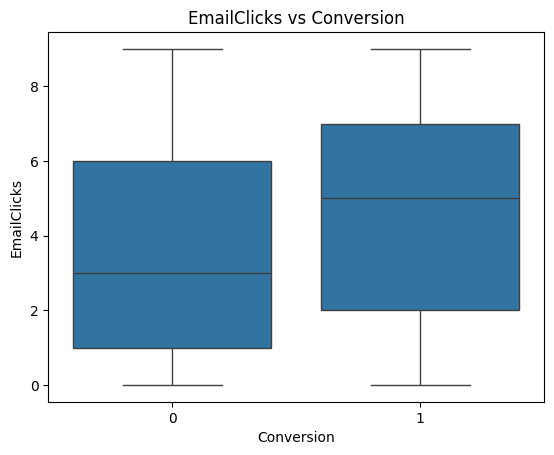

In [23]:
sns.boxplot(x='Conversion', y='EmailClicks', data=df)
plt.title("EmailClicks vs Conversion")
plt.show()

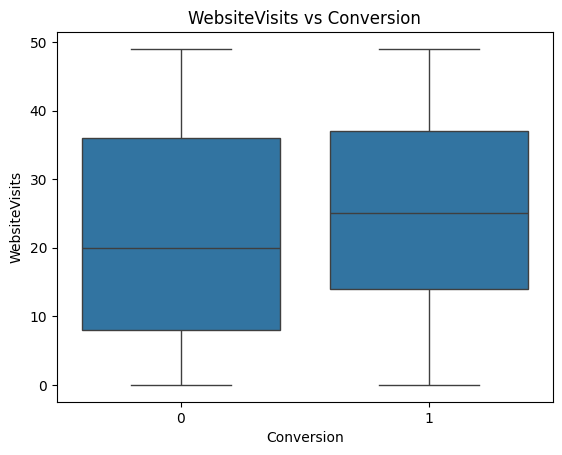

In [24]:
sns.boxplot(x='Conversion', y='WebsiteVisits', data=df)
plt.title("WebsiteVisits vs Conversion")
plt.show()

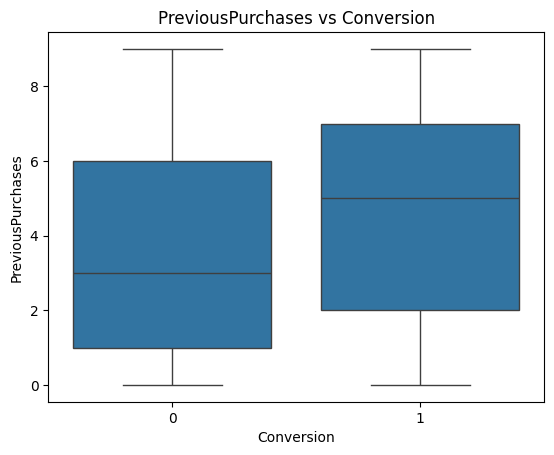

In [25]:
sns.boxplot(x='Conversion', y='PreviousPurchases', data=df)
plt.title("PreviousPurchases vs Conversion")
plt.show()

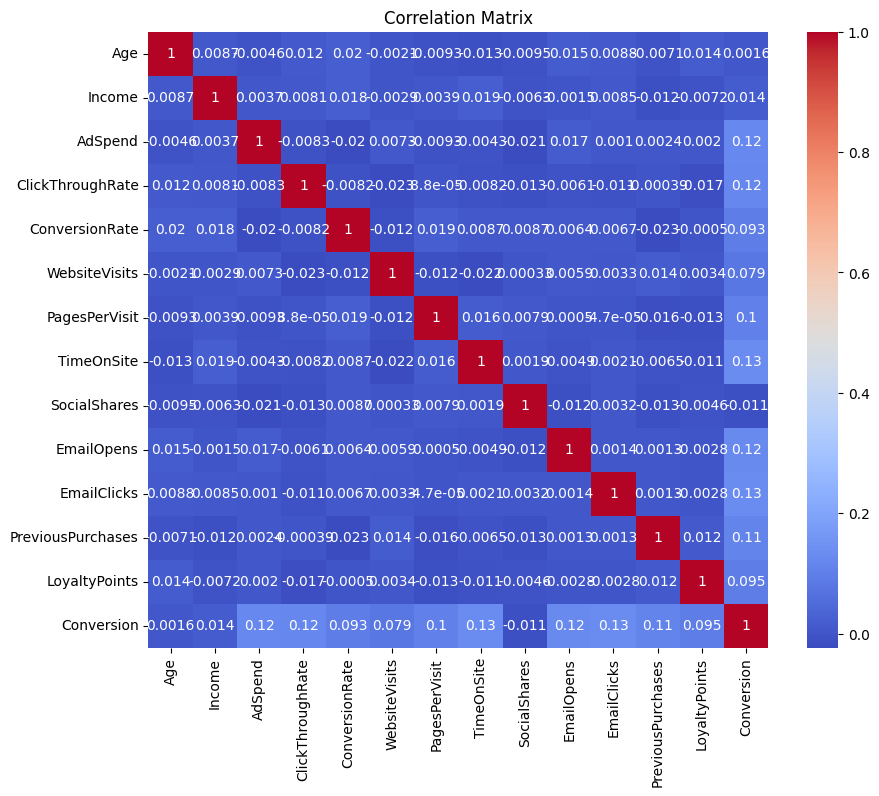

In [26]:
# correlation analysis
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [27]:
# key drivers of conversion
df.corr(numeric_only=True)['Conversion'].sort_values(ascending=False)

Conversion           1.000000
TimeOnSite           0.129609
EmailClicks          0.129521
EmailOpens           0.124884
AdSpend              0.124672
ClickThroughRate     0.120012
PreviousPurchases    0.111781
PagesPerVisit        0.102840
LoyaltyPoints        0.095004
ConversionRate       0.093185
WebsiteVisits        0.079339
Income               0.013974
Age                  0.001606
SocialShares        -0.011449
Name: Conversion, dtype: float64

In [28]:
# channel performance analysis
channel_summary = df.groupby('CampaignChannel').agg({
    'AdSpend': 'mean',
    'ClickThroughRate': 'mean',
    'WebsiteVisits': 'mean',
    'Conversion': 'mean'
}).sort_values(by='Conversion', ascending=False)

print(channel_summary)

                     AdSpend  ClickThroughRate  WebsiteVisits  Conversion
CampaignChannel                                                          
Referral         5034.042284          0.151673      24.890634    0.883072
PPC              4954.221741          0.158307      24.155287    0.882779
SEO              4994.131533          0.153150      24.740000    0.876774
Email            5055.604272          0.155609      24.878613    0.870263
Social Media     4965.321428          0.155523      25.125741    0.868334


In [29]:
# campaign type performance
campaign_summary = df.groupby('CampaignType').agg({
    'AdSpend': 'mean',
    'ClickThroughRate': 'mean',
    'Conversion': 'mean'
}).sort_values(by='Conversion', ascending=False)

print(campaign_summary)

                   AdSpend  ClickThroughRate  Conversion
CampaignType                                            
Conversion     4959.112653          0.155665    0.933558
Retention      5017.135162          0.156076    0.858243
Awareness      5069.338947          0.155764    0.855634
Consideration  4960.399233          0.151798    0.855634


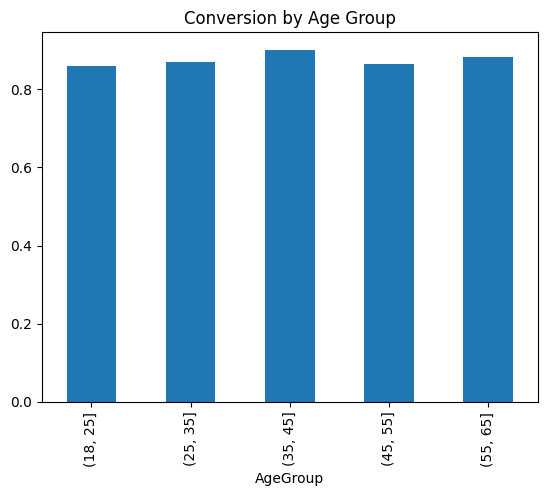

In [30]:
# customer segmentation - age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,55,65])

df.groupby('AgeGroup')['Conversion'].mean().plot(kind='bar')
plt.title("Conversion by Age Group")
plt.show()

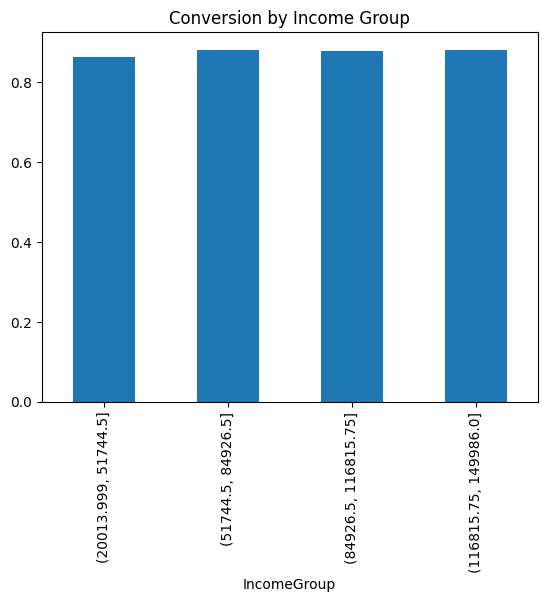

In [31]:
# customer segmentation - income groups
df['IncomeGroup'] = pd.qcut(df['Income'], q=4)

df.groupby('IncomeGroup')['Conversion'].mean().plot(kind='bar')
plt.title("Conversion by Income Group")
plt.show()

In [32]:

# Make a copy for modeling
model_df = df.copy()

# Separate predictors and target
X = model_df.drop("Conversion", axis=1)
y = model_df["Conversion"]

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (8000, 28)
Target shape: (8000,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (6400, 28)
Testing set: (1600, 28)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7425
Logistic Regression ROC-AUC: 0.78171875675442
              precision    recall  f1-score   support

           0       0.29      0.73      0.41       198
           1       0.95      0.74      0.84      1402

    accuracy                           0.74      1600
   macro avg       0.62      0.74      0.62      1600
weighted avg       0.87      0.74      0.78      1600

[[ 145   53]
 [ 359 1043]]


In [37]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, y_prob_tree))
print(classification_report(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Accuracy: 0.72625
Decision Tree ROC-AUC: 0.7082720932578279
              precision    recall  f1-score   support

           0       0.25      0.61      0.35       198
           1       0.93      0.74      0.83      1402

    accuracy                           0.73      1600
   macro avg       0.59      0.67      0.59      1600
weighted avg       0.85      0.73      0.77      1600

[[ 120   78]
 [ 360 1042]]


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.911875
Random Forest ROC-AUC: 0.813318635715212
              precision    recall  f1-score   support

           0       0.73      0.46      0.56       198
           1       0.93      0.98      0.95      1402

    accuracy                           0.91      1600
   macro avg       0.83      0.72      0.76      1600
weighted avg       0.90      0.91      0.90      1600

[[  91  107]
 [  34 1368]]


In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(model_results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.742500   0.951642  0.743937  0.835068  0.781719
1        Decision Tree  0.726250   0.930357  0.743224  0.826328  0.708272
2        Random Forest  0.911875   0.927458  0.975749  0.950991  0.813319


In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [41]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

              Feature  Importance
7          TimeOnSite    0.103918
6       PagesPerVisit    0.101632
3    ClickThroughRate    0.100803
2             AdSpend    0.092202
11  PreviousPurchases    0.082276
12      LoyaltyPoints    0.076308
4      ConversionRate    0.074274
10        EmailClicks    0.067404
9          EmailOpens    0.065273
5       WebsiteVisits    0.053214


In [42]:
log_coeff = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(log_coeff.head(10))
print(log_coeff.tail(10))

                    Feature  Coefficient
3          ClickThroughRate     0.452612
7                TimeOnSite     0.442696
10              EmailClicks     0.420279
2                   AdSpend     0.386874
9                EmailOpens     0.381707
12            LoyaltyPoints     0.364968
11        PreviousPurchases     0.360714
19  CampaignType_Conversion     0.314397
6             PagesPerVisit     0.297840
4            ConversionRate     0.262179
                             Feature  Coefficient
16               CampaignChannel_SEO     0.031780
26  IncomeGroup_(84926.5, 116815.75]     0.021856
20            CampaignType_Retention     0.014868
18        CampaignType_Consideration     0.011286
17      CampaignChannel_Social Media     0.003710
21                 AgeGroup_(25, 35]    -0.016356
1                             Income    -0.030444
23                 AgeGroup_(45, 55]    -0.030493
8                       SocialShares    -0.031806
0                                Age    -0.045671

In [43]:
channel_summary = df.groupby("CampaignChannel").agg({
    "Conversion": "mean",
    "AdSpend": "mean",
    "ClickThroughRate": "mean",
    "WebsiteVisits": "mean",
    "EmailClicks": "mean"
}).sort_values(by="Conversion", ascending=False)

print(channel_summary)

                 Conversion      AdSpend  ClickThroughRate  WebsiteVisits  \
CampaignChannel                                                             
Referral           0.883072  5034.042284          0.151673      24.890634   
PPC                0.882779  4954.221741          0.158307      24.155287   
SEO                0.876774  4994.131533          0.153150      24.740000   
Email              0.870263  5055.604272          0.155609      24.878613   
Social Media       0.868334  4965.321428          0.155523      25.125741   

                 EmailClicks  
CampaignChannel               
Referral            4.527632  
PPC                 4.461631  
SEO                 4.322581  
Email               4.513166  
Social Media        4.506254  


In [44]:
campaign_type_summary = df.groupby("CampaignType").agg({
    "Conversion": "mean",
    "AdSpend": "mean",
    "ClickThroughRate": "mean",
    "WebsiteVisits": "mean",
    "EmailClicks": "mean"
}).sort_values(by="Conversion", ascending=False)

print(campaign_type_summary)

               Conversion      AdSpend  ClickThroughRate  WebsiteVisits  \
CampaignType                                                              
Conversion       0.933558  4959.112653          0.155665      24.376023   
Retention        0.858243  5017.135162          0.156076      24.581921   
Awareness        0.855634  5069.338947          0.155764      24.759557   
Consideration    0.855634  4960.399233          0.151798      25.302314   

               EmailClicks  
CampaignType                
Conversion        4.544535  
Retention         4.421161  
Awareness         4.402918  
Consideration     4.496479  
